# Sentiment Analysis of Customer Reviews

Christoph Stelz, Celio Bueri


This is the accompanying code for our report “Sentiment Analysis of Customer Reviews”.
The dependencies needed to run this notebook are:
* Pandas/NumPy/Matplotlib
* Seaborn
* scikit-learn
* keras/keras_nlp (optional, for BERT only)

**Notes on running the notebook**
The BERT model take a lot of compute if GPU acceleration can not be used. Therefore, if you do not have a CUDA GPU it is advised to not run these sections.
The final accuracy graphic is designed in such a way that it should simply omit the values from the large language models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")

First we load the training data and transform it into 2 collums X and y

In [2]:
# Read the data file.
data_train = pd.read_table("PA3_train.tsv", header=None)
data_train['review'] = data_train[1]
data_train['opinion1'] = data_train[0].map(lambda x : x.split('/')[0])
data_train['opinion2'] = data_train[0].map(lambda x : x.split('/')[1])

# is the 2 opinions the same ?
data_train['opinions_agreed'] = data_train['opinion1'] == data_train['opinion2']

# if there is a disagreement then -1 (indetermined class)
data_train['opinion'] = np.where(data_train['opinions_agreed'], data_train['opinion1'].astype('int'), -1)

# Only keeps the review where all annotator agreed
data_train = data_train[data_train['opinion1'] == data_train['opinion2']]

# Only keeps the two columns
data_train = data_train[['review', 'opinion']]

Next, we split the data into a train set and a validation set.

In [3]:
from sklearn.model_selection import train_test_split

X = data_train['review']
Y = data_train['opinion']

# split training and test dataset, also randomize the data
X_train, X_val, Y_train, Y_val = train_test_split(X,Y, train_size = 0.66, shuffle = True)

Finally, we load the test data set to be used at the very end.

In [4]:
data_val = pd.read_table("PA3_test.tsv", header=None)

X_test = data_val[1]
Y_test = data_val[0]

## Bag of words approach

For the Bag of words approach we will compare 3 linear classifiers:
 - LinearSVC
 - GradientBoostingClassifier
 - LogisticRegression

 For LinearSVC and LogisticRegression we use a L1 regulizer.

We use a pipeline with a Vectorizer and a transformer to convert the data into a bag of words format.

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


pipelineSVC = make_pipeline(
  CountVectorizer(),
	TfidfTransformer(),
  LinearSVC(random_state=0, penalty='l1', loss='squared_hinge', dual=False)
)

pipelineLogistic = make_pipeline(
  CountVectorizer(),
	TfidfTransformer(),
  LogisticRegression(penalty="l1", solver="liblinear", random_state=0)
)

pipelineGBC = make_pipeline(
  CountVectorizer(),
	TfidfTransformer(),
  GradientBoostingClassifier(random_state=0)
)

In [6]:
pipeline = make_pipeline(
  CountVectorizer(),
	TfidfTransformer()
)

pipeline.fit(X_train, Y_train)
len(pipeline[1].get_feature_names_out())

9386

Fit the model to the training data

In [7]:
pipelineSVC.fit(X_train, Y_train)
pipelineLogistic.fit(X_train, Y_train)
pipelineGBC.fit(X_train, Y_train)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('tfidftransformer', TfidfTransformer()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(random_state=0))])

We compare the classifiers with the accuracy

In [8]:
from sklearn.metrics import accuracy_score

classifiers = [
    ("SVC\t\t", pipelineSVC),
    ("Logistic regression", pipelineLogistic),
    ("Gradient boosting", pipelineGBC)
]
print("Classifier\t\tTrain\t\tValidation")
for name,c in classifiers:
    acc_train = accuracy_score(c.predict(X_train), Y_train)
    acc_val = accuracy_score(c.predict(X_val), Y_val)
    print(f"{name}\t{acc_train*100:.5f}%\t{acc_val*100:.5f}%")

Classifier		Train		Validation
SVC			98.85584%	95.29307%
Logistic regression	94.98856%	94.22735%
Gradient boosting	94.48513%	91.42984%


The best of these three models is the linear SVC.

## Hyperparameter Tuning

### SVM

We are using the hyperparameter C (Regularization parameter) in SVC model with a grid search.

In [9]:
param_grid = {'svc__C': 0.1*np.array(range(1, 31, 1))}

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipelineSVCopt = Pipeline(steps=[
  ("vect",CountVectorizer()),
  ("transform", TfidfTransformer()),
  ("svc", LinearSVC(random_state=0, penalty='l1', loss='squared_hinge', dual=False))
])

# Grid search for hyperparameter C on the training data set
grid_search = GridSearchCV(pipelineSVCopt, param_grid, n_jobs=-1, return_train_score=True)

grid_search.fit(X, Y)

print("Best parameter C (accuracy=%0.3f):" % grid_search.best_score_)
print(grid_search.best_params_)

Best parameter C (accuracy=0.958):
{'svc__C': 1.0}


To get a clearer image, we plot the accuracy over the adjusted hyper-parameter:

/tmp/ipykernel_89609/1707769768.py:13: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  f.show()


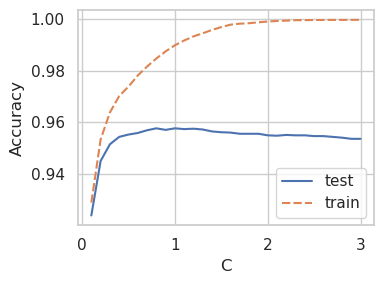

In [11]:
f, ax = plt.subplots(figsize=(4,3))
df = pd.DataFrame.from_records((param_grid['svc__C'], 
                                grid_search.cv_results_['mean_test_score'],
                                grid_search.cv_results_['mean_train_score'])).transpose()
df = df.set_index(0).rename(columns={1: 'test', 2: 'train'})

sns.lineplot(df)

ax.set_ylabel('Accuracy')
ax.set_xlabel('C')
f.tight_layout()
f.savefig('figures/svm_accuracy.svg')
f.show()

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


print("Accuracy = ", grid_search.best_score_)
print("Confusion matrix :\n", confusion_matrix(Y_val, grid_search.best_estimator_.predict(X_val)))

Accuracy =  0.9577170381348686
Confusion matrix :
 [[1048   11]
 [  14 1179]]


We will now look at our list of words that have the highest weight

In [13]:
words_coefficient = pd.DataFrame(zip(grid_search.best_estimator_.steps[0][1].get_feature_names_out(), grid_search.best_estimator_.steps[2][1].coef_[0]), columns=['word','coefficient'])
words_coefficient = words_coefficient.sort_values("coefficient", ascending=False)

We print the 10 most positive words

In [14]:
words_coefficient.head(10)

,word,coefficient
2874,delicious,7.957972
3684,excellent,6.549877
577,amazing,5.957790
4550,great,5.354539
7377,perfect,5.122644
1216,best,4.057902
6025,loved,3.885160
4370,generous,3.752286
4470,good,3.682603
1740,cantonese,3.293152


And the 10 most negative words

In [15]:
words_coefficient.tail(10).iloc[::-1]

,word,coefficient
11212,worst,-7.197251
6851,not,-6.205678
3325,dry,-5.072820
3072,disappointing,-4.915437
8517,rude,-4.812884
6328,mediocre,-4.630066
7619,poor,-4.586730
10065,terrible,-4.485604
7127,overpriced,-4.149879
9968,tasteless,-4.036874


In [16]:
# Write to csv for wordcloud visualization
words_coefficient.head(20).to_csv('positive_words.csv', index=False)
words_coefficient.tail(20).iloc[::-1].to_csv('negative_words.csv', index=False)

We can look at the reviews that have caused problems for our classifier

In [17]:
# Predictions
Y_pred = grid_search.best_estimator_.predict(X_val)

# indices where the classifier is wrong
misclassified_indices = Y_val != Y_pred

misclassified = pd.DataFrame()
misclassified["review"] = X_val[misclassified_indices]
misclassified["true_class"] = Y_val[misclassified_indices]
misclassified["predicted"] = Y_pred[misclassified_indices]


print(misclassified)

                                                 review  true_class  predicted
187   Food was really good but the service could hav...           0          1
6544  Absolutely wanted to visit this place because ...           0          1
3519  There is not much to say about this place othe...           1          0
2421  They looked tasty, but we discovered they were...           0          1
3293  I dine here every now and then and have never ...           1          0
5341  This was our second visit. The main course is ...           0          1
5491  Our Waiter, Claudio was very Italian & very pr...           1          0
888           Still the place to be, even a year later.           1          0
5120  Food came out in a clean manner. Bit of a wait...           1          0
6892  the pizza was cold... i decided i wouldn't try...           0          1
5964  You wonder sometimes why certain restaurants a...           0          1
1377  We were looking for a nice cake, with a coffee

### Using 2-grams

Up until now, `CountVectorizer` only considered single words as feature. By increasing the n-gram-range to 2, our classifier will get combinations of two words as input. For example, 'not good' would be considered a single feature.

Because the Bag of Words representation does not make use of positional encoding, this could improve the accuracy by increasing available context.

In [18]:
param_grid = {'svc__C': 0.1*np.array(range(1, 14, 1))}
pipelineSVC2 = Pipeline(steps=[
  ("vect",CountVectorizer(ngram_range=(1,2))),
  ("transform", TfidfTransformer()),
  ("svc", LinearSVC(random_state=0, penalty='l1', loss='squared_hinge', dual=False))
])

# Grid search for hyperparameter C on the training data set
grid_search2 = GridSearchCV(pipelineSVC2, param_grid, n_jobs=-1, return_train_score=True)

grid_search2.fit(X, Y)

print("Best parameter C (accuracy=%0.3f):" % grid_search2.best_score_)
print(grid_search2.best_params_)

Best parameter C (accuracy=0.958):
{'svc__C': 1.2000000000000002}


In [19]:
print("Accuracy = ", grid_search2.best_score_)
print("Confusion matrix :\n", confusion_matrix(Y_val, grid_search2.best_estimator_.predict(X_val)))

Accuracy =  0.9581694123012028
Confusion matrix :
 [[1050    9]
 [  19 1174]]


The grid search finds a different hyperparameter for regularization, but the accuracy did not improve.

## Another approach with a more complex model

We are using the pretrained [BERT model](https://en.wikipedia.org/wiki/BERT_(language_model)) and fine-tune it to our dataset.
For a first test, we use the [tiny variant](https://huggingface.co/prajjwal1/bert-tiny) which has $L=2$ transformer blocks / layers and a hidden size of $H=128$.

In [19]:
%%capture
!pip install keras_nlp

In [20]:
import keras_nlp
import tensorflow as tf
from tensorflow import keras

keras.mixed_precision.set_global_policy("mixed_float16")

bertClassifier = keras_nlp.models.BertClassifier.from_preset(
    "bert_tiny_en_uncased",
    num_classes=2
)

Time to finetune the classifier. This takes a long time if done without GPU acceleration. To save energy, we save our weights to disk. Set `finetune = False` to load the trained weights from the disk again.

In [21]:
finetune = False

if finetune:
  bertClassifier.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=6)
  bertClassifier.save_weights("bert_tiny")
  bertTinyHistory = bertClassifier.history.history
else:
  bertClassifier.load_weights("bert_tiny")

In [22]:
# Preserve history for plots
if finetune:
    with open('bert_tiny_history', 'w') as f:
        json.dump(bertTinyHistory, f)
else:
    with open('bert_tiny_history') as f:
        bertTinyHistory = json.load(f)


In [23]:
Y_pred = np.array([1 if x[1]>0 else 0 for x in bertClassifier.predict(X_val)])

print("Accuracy = ", sum(Y_val==Y_pred)/len(Y_val))
print("Confusion matrix :\n", confusion_matrix(Y_val, Y_pred))

71/71 [==============================] - 18s 124ms/step
Accuracy =  0.9822380106571936
Confusion matrix :
 [[1035    9]
 [  31 1177]]


We also plot the validation and training accuracy over the course of training.

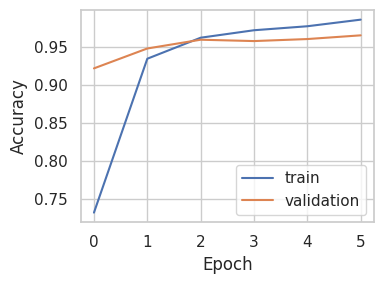

In [24]:
h = bertTinyHistory

f, ax = plt.subplots(figsize=(4,3))
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
sns.lineplot(h['sparse_categorical_accuracy'], label='train')
sns.lineplot(h['val_sparse_categorical_accuracy'], label='validation')
f.tight_layout()
f.savefig("figures/bert_tiny_accuracy.svg")
plt.show()

We can look at the reviews that have caused problems for this classifier

In [25]:
# indices where the classifier is wrong
misclassified_indices = Y_val != Y_pred

misclassified = pd.DataFrame()
misclassified["review"] = X_val[misclassified_indices]
misclassified["true_class"] = Y_val[misclassified_indices]
misclassified["predicted"] = Y_pred[misclassified_indices]


print(misclassified)

                                                 review  true_class  predicted
5213  A Rathmines restaurant that will please all di...           1          0
3930  If you're not sure - or if you want to be sure...           1          0
1310  Never expected to find anything like this rest...           1          0
5601  Noodles are very very tasty. Queue moves quick...           1          0
5417  Even if the café wants to keep its original st...           0          1
6111  This small restaurant (only a few tables) is w...           1          0
4935  This is one of these classic places where you ...           0          1
2589  Didn't take too long to get my order and it wa...           1          0
6241  We came upon this restaurant on a quiet back s...           1          0
5393  Spectacular food and service!!! Not cheap but ...           1          0
6891  My daughter ordered a burger. Our server broug...           1          0
3960  I ate here last weekend while on vacation with

## BERT Base

Now we try to fine-tune the larger model, BERT Base.
This has $L = 12$ transformer blocks and a hidden size of $H = 768$.

Note that fine-tuning this larger model takes much longer and using a GPU (for example on Google Colab) is highly recommended.

In [26]:
bertBaseClassifier = keras_nlp.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=2
)

In [27]:
finetune = False

if finetune:
  bertBaseClassifier.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=4)
  bertBaseClassifier.save_weights("bert_base")
else:
  bertBaseClassifier.load_weights("bert_base")

In [28]:
# Preserve history for plots
if finetune:
    with open('bert_base_history', 'w') as f:
        bertBaseHistory = bertBaseClassifier.history.history
        json.dump(bertBaseHistory, f)
else:
    with open('bert_base_history') as f:
        bertBaseHistory = json.load(f)

Once again we plot training and validation accuracy over the course of the training. Because we only trained for a small amount of epochs, the line plot is not as clear as the one above. However, we can see that the validation accuracy already starts oscillating.

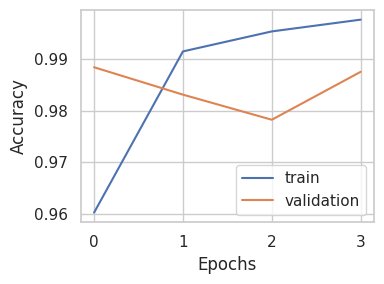

In [29]:
h = bertBaseHistory

f, ax = plt.subplots(figsize=(4,3))
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy')
sns.lineplot(h['sparse_categorical_accuracy'], label='train')
sns.lineplot(h['val_sparse_categorical_accuracy'], label='validation')
f.tight_layout()
f.savefig("figures/bert_base_accuracy.svg")
plt.show()

In [30]:
Yb_pred = np.array([1 if x[1]>0 else 0 for x in bertBaseClassifier.predict(X_val)])

71/71 [==============================] - 40s 372ms/step


In [31]:
print(f"Accuracy {100 * sum(Y_val==Yb_pred)/len(Y_val):.5f}%")
print("Confusion matrix :\n", confusion_matrix(Y_val, Yb_pred))

Accuracy 99.51155%
Confusion matrix :
 [[1040    4]
 [   7 1201]]


## Extended dataset

The extended dataset contains an additional label for each review.
We will perform a majority vote to obtain the label used for training the classifiers.
That means we need at least two votes for one label for it to be considered correct:

* 0/0/-1 ⇒ 0
* 1/0/1 ⇒ 1
* -1/-1/0 ⇒ -1

In the last case, we do not trust the single correct label.

In [20]:
def majority_vote(x):
    votes = x.split('/')
    ones = votes.count('1')
    zeros = votes.count('0')
    
    if zeros >= 2:
        return 0
    elif ones >= 2:
        return 1
    else:
        return -1
        
data_train_ext = pd.read_table("PA3_train_final.tsv", header=None, encoding='utf-8')
n_total = len(data_train_ext.index)


data_train_ext['review'] = data_train_ext[1]
data_train_ext['opinion'] = data_train_ext[0].map(majority_vote)
data_train_ext = data_train_ext[data_train_ext['opinion'] != -1]
n_total_valid = len(data_train_ext.index)

n_discarded = n_total - n_total_valid
print(f"Discarded {n_discarded} rows ({100 * n_discarded / n_total:.1f}%) from set because of invalid annotations")

Discarded 100 rows (1.3%) from set because of invalid annotations


Next, we split our dataset again. We append a single 'f' to each variable to label them as the 'final' training set.

In [21]:
Xf = data_train_ext['review']
Yf = data_train_ext['opinion']

# split training and test dataset, also randomize the data
Xf_train, Xf_val, Yf_train, Yf_val = train_test_split(Xf, Yf, train_size = 0.66, shuffle = True)

We rerun the best classifiers we found above:

* SVM with $C = 1.0$ and a monogram `CountVectorizer`
* BERT Base fine-tuned for 2 epochs

In [22]:
pipelineSVCf = make_pipeline(
    CountVectorizer(),
    TfidfTransformer(),
    LinearSVC(random_state=0, penalty='l1', loss='squared_hinge', C=1.0, dual=False)
)

pipelineSVCf.fit(Xf_train, Yf_train)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('tfidftransformer', TfidfTransformer()),
                ('linearsvc',
                 LinearSVC(dual=False, penalty='l1', random_state=0))])

In [23]:
print(f"SVC: {100*accuracy_score(pipelineSVCf.predict(Xf_val), Yf_val):.5f}%")

SVC: 94.69814%


In [36]:
bertBasefClassifier = keras_nlp.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    num_classes=2
)

In [37]:
finetune = False

if finetune:
  bertBasefClassifier.fit(Xf_train, Yf_train, validation_data=(Xf_val, Yf_val), epochs=2)
  bertBasefClassifier.save_weights("bertf_base")
else:
  bertBasefClassifier.load_weights("bertf_base")

In [38]:
# Preserve history for plots
if finetune:
    with open('bert_basef_history', 'w') as f:
        bertBasefHistory = bertBasefClassifier.history.history
        json.dump(bertBasefHistory, f)
else:
    with open('bert_basef_history') as f:
        bertBasefHistory = json.load(f)

In [39]:
Yf_pred = np.array([1 if x[1]>0 else 0 for x in bertBasefClassifier.predict(Xf_val)])


81/81 [==============================] - 42s 404ms/step


In [40]:
print(f"Accuracy {100 * sum(Yf_val==Yf_pred)/len(Yf_val):.5f}%")
print("Confusion matrix :\n", confusion_matrix(Yf_val, Yf_pred))

Accuracy 99.07121%
Confusion matrix :
 [[1210   13]
 [  11 1350]]


## Final testing of all classifiers

Up until now, we only ever used validation data derived from our training data to evaluate the different classifiers.
We now will use the test data set for a final performance review of all classifiers.

In [24]:
final_accuracy = {}

### Linear classifiers

In [25]:
for name, classifier in [
    ('Logistic', pipelineLogistic),
    ('Gradient-boosting', pipelineGBC),
    ('SVC', pipelineSVC),
    ('SVC C=1', grid_search.best_estimator_),
    ('SVC 1-2-grams', grid_search2.best_estimator_),
    ('SVC final dataset', pipelineSVCf)]:
    final_accuracy[name] = accuracy_score(Y_test, classifier.predict(X_test))

### Transformer models

In [46]:
for name, model in [
    ('BERT Tiny', bertClassifier),
    ('BERT Base', bertBaseClassifier),
    ('BERT Base final dataset', bertBasefClassifier)]:
    Y_pred = np.array([1 if x[1]>0 else 0 for x in model.predict(X_test)])
    final_accuracy[name] = accuracy_score(Y_test, Y_pred)

55/55 [==============================] - 23s 403ms/step


In [26]:
final_accuracy

{'Logistic': 0.9354654483152485,
 'Gradient-boosting': 0.9154768703597944,
 'SVC': 0.9531696173615077,
 'SVC C=1': 0.9651627641347801,
 'SVC 1-2-grams': 0.9605939463163906,
 'SVC final dataset': 0.9560251284980011}

Now we render the accuracy as bar plots.

In [27]:
acc_df = pd.DataFrame.from_dict(final_accuracy, orient='index') \
            .sort_values(by=0).transpose()

acc_df

,Gradient-boosting,Logistic,SVC,SVC final dataset,SVC 1-2-grams,SVC C=1
0,0.915477,0.935465,0.95317,0.956025,0.960594,0.965163


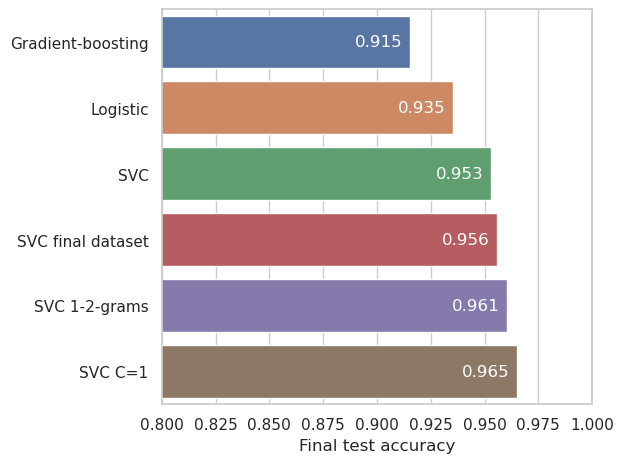

In [28]:
f, ax = plt.subplots()

ax.set_xlim(0.8, 1.0)
ax.set_xlabel('Final test accuracy')
sns.set_color_codes('pastel')
sns.barplot(data=acc_df, orient='h')

ax.bar_label(ax.containers[-1], fmt='%.3f', padding=-40, color='white')
f.tight_layout()
f.savefig('figures/accuracy_barplot.pdf')

In [24]:
%%timeit
pipelineSVC.predict(X_test)

66.7 ms ± 12.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
len(X_test)

1751